In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
data_df = pd.read_csv("data/gencodev44_DD_RGC_integration.tsv", sep="\t")

# Load gene sets
DD_gene_set = [
    line.strip() for line in open("data/denovoWEST_DD-related_gene.lst", "r")
]
RDH_gene_set = []
with open("../Fig1/data/Human.gencodev44.histone.tsv", "r") as f:
    f.readline()
    for line in f:
        fields = line.strip().split()
        if fields[-1] == "RDH":
            RDH_gene_set.append(fields[1])

# Annotate
data_df["is_DD"] = data_df["gene_name"].map(lambda x: x in DD_gene_set)
data_df["is_cRDH"] = data_df["gene_name"].map(
    lambda x: (x in RDH_gene_set) and ("H1" not in x)
)
data_df["is_other"] = data_df.apply(
    lambda row: (not row["is_DD"]) and (not row["is_cRDH"]), axis=1
)

In [3]:
plot_df_lst = []

# Get relative enrichment
for gene_category in ['DD', 'cRDH', 'other']:

    subset = data_df[data_df[f'is_{gene_category}']]

    dd_dnm_syn = subset['DDdenovo_syn'].sum()
    dd_dnm_mis = subset['DDdenovo_mis'].sum()

    rgc_syn = subset['RGC-ME_syn'].sum()
    rgc_mis = subset['RGC-ME_mis'].sum()

    gnomad_syn = subset['gnomAD_syn'].sum()
    gnomad_mis = subset['gnomAD_mis'].sum()

    odds_ratio1, p_value1 = fisher_exact(
        [[dd_dnm_mis, dd_dnm_syn], [rgc_mis, rgc_syn]], alternative='greater'
    )
    odds_ratio2, p_value2 = fisher_exact(
        [[dd_dnm_mis, dd_dnm_syn], [gnomad_mis, gnomad_syn]], alternative='greater'
    )

    plot_df_lst.append({
        'gene_category': gene_category,
        'comparison': 'RGC-ME rare',
        'odds_ratio': odds_ratio1,
        'p_value': p_value1,
        'DD n.mis': dd_dnm_mis,
        'DD n.syn': dd_dnm_syn,
        'control n.mis': rgc_mis,
        'control n.syn': rgc_syn,
    })
    plot_df_lst.append({
        'gene_category': gene_category,
        'comparison': 'gnomAD rare',
        'odds_ratio': odds_ratio2,
        'p_value': p_value2,
        'DD n.mis': dd_dnm_mis,
        'DD n.syn': dd_dnm_syn,
        'control n.mis': gnomad_mis,
        'control n.syn': gnomad_syn,
    })

In [4]:
plot_df = pd.DataFrame(plot_df_lst)
plot_df['log2(odds_ratio)'] = np.log2(plot_df['odds_ratio']) 

/tmp/ipykernel_133127/1417464803.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["DD-related", "core RDHs", "other genes"])
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


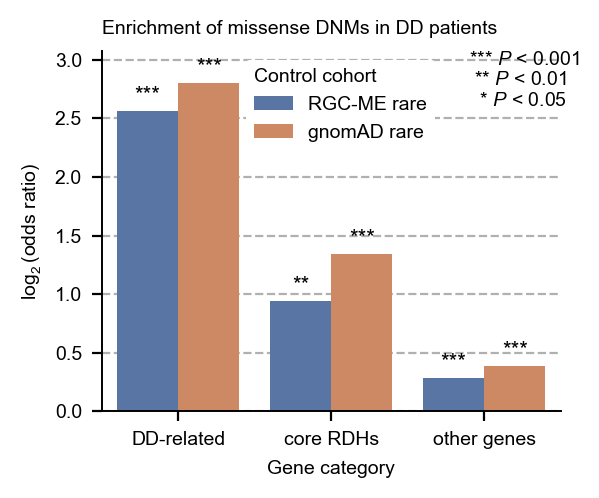

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

ax = sns.barplot(
    data=plot_df,
    x="gene_category",
    y="log2(odds_ratio)",
    hue="comparison",
    hue_order=["RGC-ME rare", "gnomAD rare"],
    palette=["#4c72b0", "#dd8452"],
    width=0.8,
    zorder=2,
)

ax.grid(axis="y", linestyle="--", zorder=-1)
ax.set_ylabel(r"$\log_2(\mathrm{odds\ ratio})$")
ax.set_xlabel("Gene category")

ax.set_xticklabels(["DD-related", "core RDHs", "other genes"])
ax.spines[["top", "right"]].set_visible(False)

ax.set_title("Enrichment of missense DNMs in DD patients", loc="left")

plt.legend(
    title="Control cohort",
    loc="upper center",
    frameon=True,
    alignment="left",
    facecolor="white",
    edgecolor="none",
    framealpha=1,
    bbox_to_anchor=(0.52, 1),
)


def get_p_symbol(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


# Iterate through bars and annotate
for patch, (idx, row) in zip(
    ax.patches, plot_df.sort_values(by="comparison").iterrows()
):
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.text(
        x,
        height + 0.05,
        get_p_symbol(row["p_value"]),
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )

ax.set_ylim(0, plot_df["log2(odds_ratio)"].max() * 1.1)
# Annotate
ax.text(
    s="*** $P$ < 0.001\n ** $P$ < 0.01\n  * $P$ < 0.05",
    x=0.8,
    y=1,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()